# 1 Likelihood Based Analysis of the 21-cm Power Spectrum
## a) PCA

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np  
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import optuna
import torch
from torch import nn, optim
import tqdm
import copy
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
# # Import simulation data
# data_dir = Path("simulations")
# files = sorted(data_dir.glob("*.npz"))

# # Define test/train/validation split
# num_files = len(files)
# train_files = files[:int(0.8 * num_files)]
# val_files = files[int(0.8 * num_files):int(0.9 * num_files)]
# test_files = files[int(0.9 * num_files):]

# # Write 
# train_simulations = []
# test_simulations = []
# val_simulations = []

# for f in train_files:
#     with np.load(f, allow_pickle=True) as d:
#         train_simulations.append(dict(d))

# for f in val_files:
#     with np.load(f, allow_pickle=True) as d:
#         val_simulations.append(dict(d))

# for f in test_files:
#     with np.load(f, allow_pickle=True) as d:
#         test_simulations.append(dict(d))

# # Unpack
# def unpack_simulations(simulations):
#     params_list = []
#     power_list  = []
#     k_list = []
#     for sim in simulations:
#         astro = sim['astro_params'].item()
#         cosmo = sim['cosmo_params'].item()
#         params_list.append([astro['L40_xray'], astro['fesc10'],
#                             astro['epsstar'],  cosmo['h_fid']])
#         power_list.append(sim['power'])
#         k_list.append(sim['k'])
#     return np.array(params_list), np.array(power_list), np.array(k_list)

# raw_params_train, power_train, k_train = unpack_simulations(train_simulations)
# raw_params_val,   power_val,   k_val   = unpack_simulations(val_simulations)
# raw_params_test,  power_test,  k_test  = unpack_simulations(test_simulations)

# # power_train = np.log(raw_power_train)
# # power_test = np.log(raw_power_test)
# # power_val = np.log(raw_power_val)

In [2]:
from helpers.load_files import load_splits
from helpers.set_seed import set_seed



set_seed(1701)
data_dir = Path("simulations")
raw_data = load_splits(data_dir)




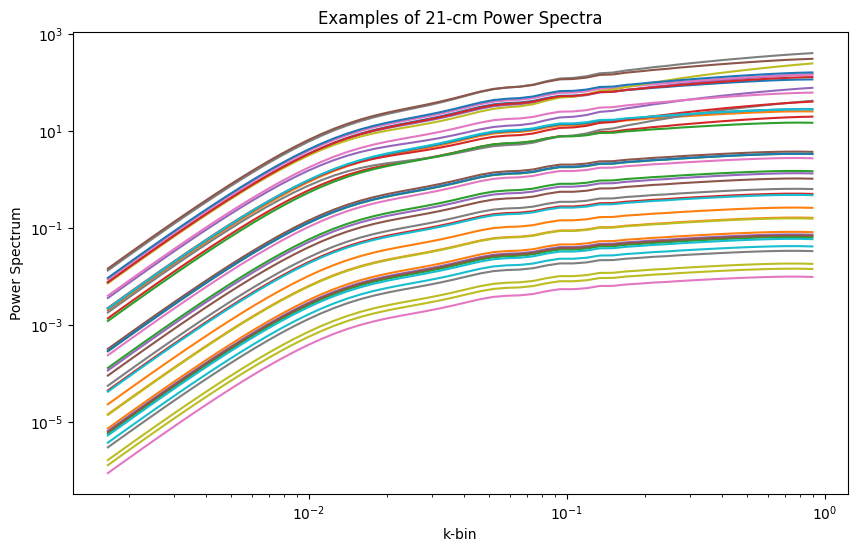

In [3]:
# Plot the power spectra examples
plt.figure(figsize=(10, 6))
for i in  range(0, 8000, 200):
    plt.loglog(raw_data['k_train'][i], raw_data['power_train'][i], label=f'Sim {i+1}')
plt.xlabel('k-bin')
plt.ylabel('Power Spectrum')
plt.title('Examples of 21-cm Power Spectra')
# plt.legend()
plt.show()

- We must normalise the training parameters as they can have different scales with respect to one another. We don't want to bias the trained NN based on the various input scales so we can scale them using a StandardScaler, which brings the mean to 0 and variance to 1.
- Each power spectrum mode has a different scale. For PCA, we want to find meaningful variations, not just the largest magnitude variations, which can be a result of different component scales. A component can have little relative variance in its axis but a huge absolute variance because of scale. As such, we normalise our power spectra as well.
- Since the power spectra vary across several orders of magnitude, it is prudent to work with the logarithm.

In [4]:
from helpers.preprocess import preprocess
processed = preprocess(raw_data, n_comp=54, log_power=True)

- Now we apply PCA on this data

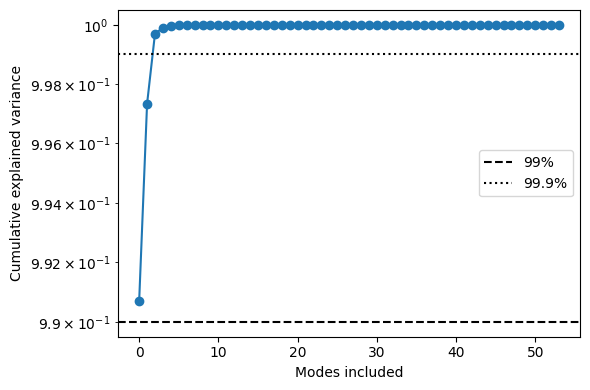

In [5]:
evecs = processed['W']
explained_variance_ratio = processed['explained_variance_ratio']
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Plot explained variance ratio
plt.figure(figsize=(6,4))
plt.yscale('log')
plt.plot(cumulative_explained_variance, marker='o')
plt.axhline(0.99, ls='--', c='k', label='99%')
plt.axhline(0.999, ls=':', c='k', label='99.9%')
plt.xlabel("Modes included")
plt.ylabel("Cumulative explained variance")
plt.legend()
plt.tight_layout()
plt.show()

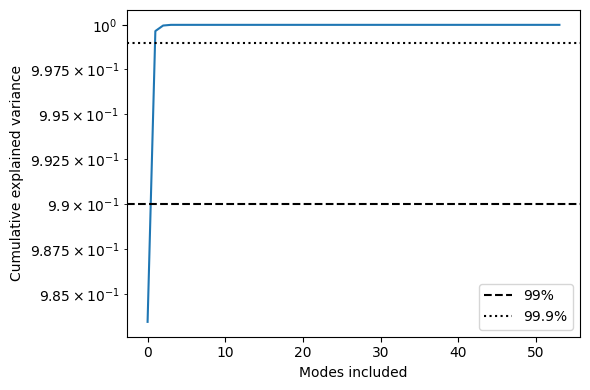

In [ ]:
# # Compute the covairance matrix of the power spectra
# power_cov = np.cov(power_train, rowvar=False)
# evals, evecs = np.linalg.eig(power_cov) # evecs are columns


# # Sort from largest to smallest eigenvalues
# args = np.argsort(evals)[::-1] # Decreasing size has to flip
# evals = np.real(evals[args])
# evecs = evecs[:, args]



# # Look at explained variance plot
# exp_var = evals / np.sum(evals)
# cum_exp_var = np.cumsum(exp_var)


# # Plot the explained variance
# plt.figure(figsize=(6,4))
# plt.yscale('log')
# plt.plot(cum_exp_var)
# plt.axhline(0.99, ls='--', c='k', label='99%')
# plt.axhline(0.999, ls=':', c='k', label='99.9%')
# plt.xlabel("Modes included")
# plt.ylabel("Cumulative explained variance")
# plt.legend()
# plt.tight_layout()
# plt.show()

In [6]:
thresholds = [0.99, 0.999, 0.9999, 0.99999, 0.999999, 0.9999999, 0.99999999]
for threshold in thresholds:
    n = np.searchsorted(cumulative_explained_variance, threshold) + 1
    print(f"{100 * threshold:.8f}% threshold explained by first {n} components")

99.00000000% threshold explained by first 1 components
99.90000000% threshold explained by first 3 components
99.99000000% threshold explained by first 5 components
99.99900000% threshold explained by first 8 components
99.99990000% threshold explained by first 11 components
99.99999000% threshold explained by first 14 components
99.99999900% threshold explained by first 18 components


- This tells us that the first three eigenvectors are all we need to describe a significant majority of the variance in the data.  It will be valid to compress the training data down using just the first three eigenvectors. 
- However, the explained variance does not correspond directly to emulator accuracy. There are a few more factors to consider:
    - The emulated likelihood may depend on some rare features which only appear in the extremes of some parameter. Because the feature is rare, this leaves a very low variance footprint in the PCA.
    - The emulated likelihood may depend on some small scale feature which looks very small in absolute variance terms.
    - The training set may not be completely representative. Some features appearing in the validation set might not appear here.
- It would not cost too much more to perform the analysis with a few more components for safety.

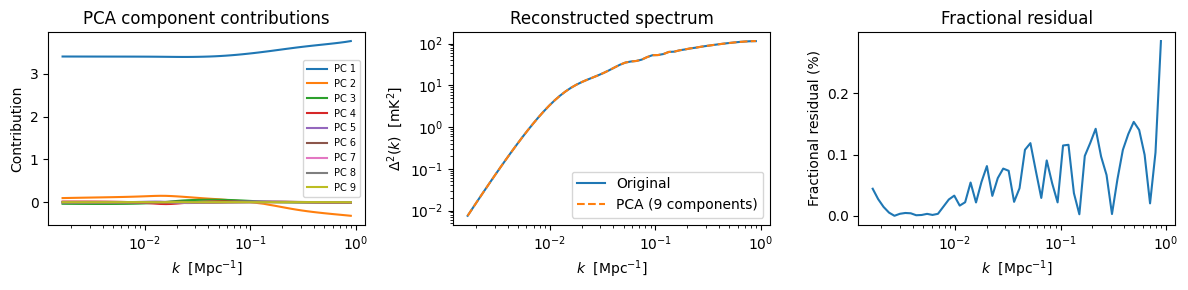

In [32]:
n_comp =9
from helpers.plotting import plot_reconstructed_train
# for i in range(0, 8000, 200):
#     _ = plot_reconstructed_train(processed, raw_data, n_comp=10, plot=True, idx=i)
_ = plot_reconstructed_train(processed, raw_data, n_comp=n_comp, plot=True, idx=0)

In [ ]:
# n_comp = 6

# # Use PCA from sklearn for stability

# pca = PCA(n_components=n_comp)
# pca.fit(power_train)

# eig_vals = pca.explained_variance_
# W = pca.components_.T

# # Project the spectra onto the top n_comp components
# projected_coeffs_train = np.real(np.dot(power_train, W)) # bc W are columns we take all rows
# projected_coeffs_test = np.real(np.dot(power_test, W))
# projected_coeffs_val = np.real(np.dot(power_val, W))

# # Check reconstructed spectra
# def check_reconstructed_spectra(power = power_train,projected_coeffs = projected_coeffs_train,idx=0, plot = False):
#     reconstructed = np.dot(projected_coeffs[idx], W.T)
    
#     frac_residual = 100 * np.abs(power[idx] - reconstructed) / np.abs(power[idx])

#     if plot == True:
#         fig, ax = plt.subplots(1, 3, figsize=(10, 3))
        
#         for i in range(n_comp):
#             ax[0].semilogx(k_train[i], projected_coeffs[idx, i] * W[:, i], label=f'E-vec {i+1}')
#         ax[0].set_xlabel(r'$k$  [Mpc$^{-1}$]')
#         ax[0].set_ylabel('Contribution')
#         ax[0].set_title('PCA components')
#         ax[0].legend(fontsize=7)
#         ax[1].loglog(k_train[0], power[idx],   label='Original')
#         ax[1].loglog(k_train[0], reconstructed, label=f'PCA with {n_comp} components)', ls='--')
#         ax[1].set_xlabel(r'$k$  [Mpc$^{-1}$]')
#         ax[1].set_ylabel(r'$\Delta^2(k)$  [mK$^2$]')
#         ax[1].set_title('Reconstructed spectrum')
#         ax[1].legend()
        
#         ax[2].semilogx(k_train[0], frac_residual)
#         ax[2].set_xlabel(r'$k$  [Mpc$^{-1}$]')
#         ax[2].set_ylabel('Fractional residual (%)')
#         ax[2].set_title('Residual')
        
#         plt.tight_layout()
#         plt.show()
#     mean_frac_residual = frac_residual.mean()
#     return mean_frac_residual

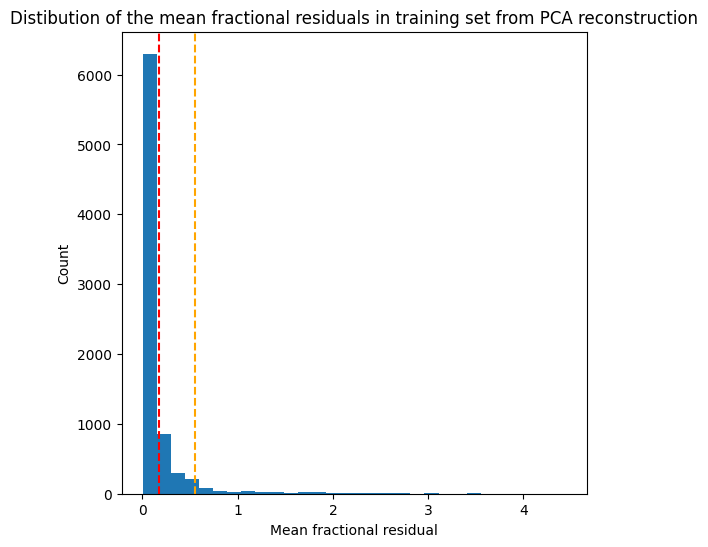

Mean fractional residual: 0.17%
95th percentile of fractional residuals: 0.55%


In [33]:
# Plot fractional residual distribution for PCA reconstruction on training set
from helpers.plotting import pca_fractional_residual
_ = pca_fractional_residual(processed, raw_data, n_comp=n_comp)

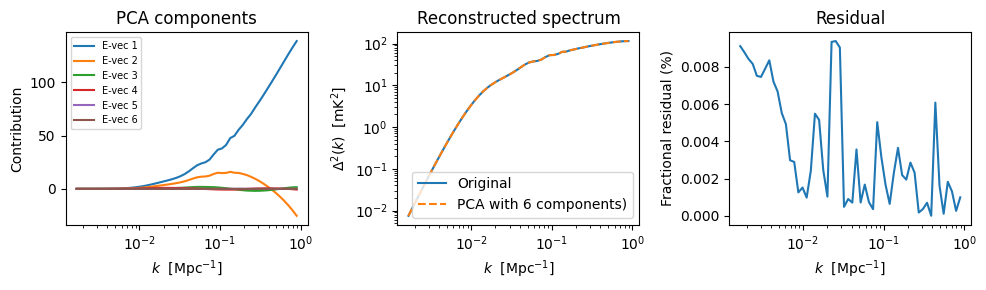

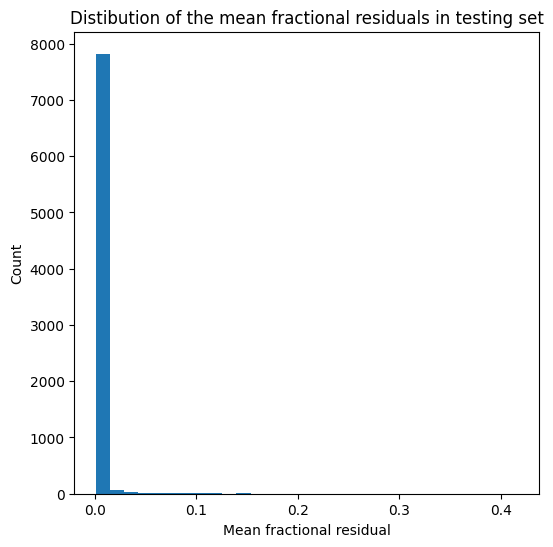

Mean fractional residual: 0.00%
95th percentile of fractional residuals: 0.01%


In [ ]:
# _ = check_reconstructed_spectra(plot = True)
# frac_residuals= []

# for j in range(0,len(projected_coeffs_train)):
#     frac_residual = check_reconstructed_spectra(idx=j)
#     frac_residuals.append(frac_residual)

# # Plot histogram of fractional residuals
# plt.figure(figsize=(6,6))
# plt.hist(frac_residuals, bins= 30)
# plt.title("Distibution of the mean fractional residuals in testing set")
# plt.xlabel("Mean fractional residual")
# plt.ylabel("Count")
# plt.show()

# # Print mean and 95th percentile of the fractional residuals
# print(f"Mean fractional residual: {np.mean(frac_residuals):.2f}%")
# print(f"95th percentile of fractional residuals: {np.percentile(frac_residuals, 95):.2f}%")

# b) NN 



In [ ]:
# Print and plot scaled and unscaled PCA coefficients to motivate scaling.
# def plot_pca_train_weights(processed, raw_data, n_comp):
#     unscaled_ranges = []
#     scaled_ranges = []
#     unscaled_params = raw_data['raw_params_train']
#     scaled_params = processed['x_train']
#     for i in range(0,n_comp):
#         feature_unscaled_weights = unscaled_params[:, i]
#         feature_scaled_weights = scaled_params[:, i]
#         unscaled_ranges.append(feature_unscaled_weights.max() - feature_unscaled_weights.min())
#         scaled_ranges.append(feature_scaled_weights.max() - feature_scaled_weights.min())

#     print("Unscaled ranges:", unscaled_ranges)
#     print("Scaled ranges:", scaled_ranges)

#     plt.figure(figsize=(6,4))

Unscaled:
Feature 0 has range 1.000e-01 to 9.999e+00 with mean 2.135e+00
Feature 1 has range 1.002e-03 to 9.996e-01 with mean 1.418e-01
Feature 2 has range 1.002e-03 to 9.995e-01 with mean 1.416e-01
Feature 3 has range 5.000e-01 to 1.000e+00 with mean 7.510e-01
Scaled:
Feature 0 has range -8.184e-01 to 3.163e+00 with mean 3.816e-09
Feature 1 has range -6.315e-01 to 3.848e+00 with mean -2.385e-09
Feature 2 has range -6.313e-01 to 3.854e+00 with mean -4.770e-10
Feature 3 has range -1.748e+00 to 1.735e+00 with mean 1.193e-08


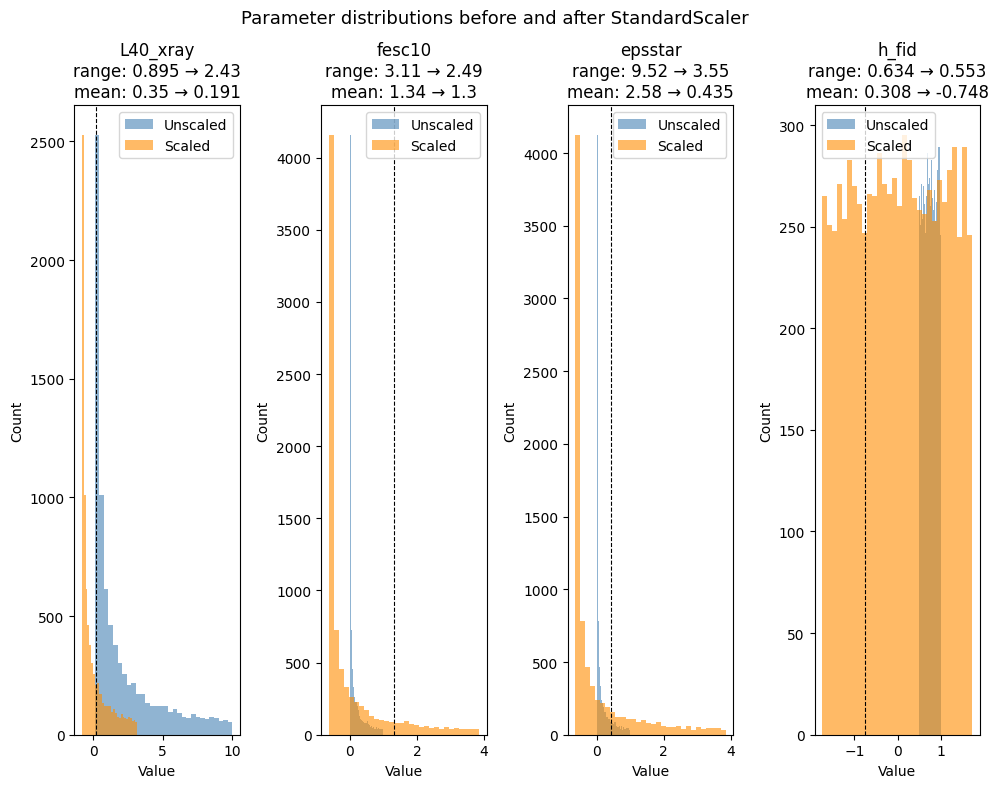

In [30]:
from helpers.plotting import plot_pca_train_weights

plot_pca_train_weights(processed,raw_data,n_comp=n_comp)


In [ ]:
# # Exmine our weight ranges and plot them

# weight_ranges = []
# for i in range(0,6):
#     feature_weights = np.real(projected_coeffs_train[:,i])
#     weight_max = max(feature_weights)
#     weight_min = min(feature_weights)
#     weight_mean = feature_weights.mean()
#     weight_ranges.append([weight_max, weight_min, weight_mean])


# for idx, weight_range in enumerate(weight_ranges):
#     print(f"Feature {idx} has range {weight_range[1]:.3e} to {weight_range[0]:.3e} with mean {weight_range[2]:.3e}")



Feature 0 has range 2.679e-02 to 1.856e+03 with mean 1.961e+02
Feature 1 has range -1.105e+02 to 2.475e+02 with mean -2.024e+00
Feature 2 has range -5.831e+01 to 1.236e+01 with mean -1.854e+00
Feature 3 has range -1.451e+01 to 5.563e+00 with mean 9.020e-01
Feature 4 has range -3.335e-01 to 6.091e-01 with mean 4.902e-03
Feature 5 has range -7.160e-02 to 3.213e-01 with mean 1.341e-02


- We should normalise each one to to have zero mean and unit variance for best NN performance.

In [ ]:
# weight_scaler =  StandardScaler().fit(projected_coeffs_train) # Normalise across the weight features on the train 

# # Now scale the test and valid set -> nomenclature for the weights will be y
# y_test = weight_scaler.transform(projected_coeffs_test)
# y_val = weight_scaler.transform(projected_coeffs_val)
# y_train = weight_scaler.transform(projected_coeffs_train)
  

NameError: name 'projected_coeffs_train' is not defined

In [ ]:
# x_train = torch.tensor(params_train, dtype=torch.float32)
# x_val   = torch.tensor(params_val, dtype=torch.float32)
# x_test  = torch.tensor(params_test, dtype=torch.float32)

# y_train = torch.tensor(y_train, dtype=torch.float32)
# y_val   = torch.tensor(y_val, dtype=torch.float32)
# y_test  = torch.tensor(y_test, dtype=torch.float32)



In [ ]:
# # Exmine our new weight ranges
# weight_ranges = []
# for i in range(0,6):
#     feature_weights = np.real(y_train[:,i])
#     weight_max = max(feature_weights)
#     weight_min = min(feature_weights)
#     weight_mean = feature_weights.mean()
#     weight_ranges.append([weight_max, weight_min, weight_mean])
# for idx, weight_range in enumerate(weight_ranges):
#     print(f"Transformed feature {idx} has range {weight_range[1]:.3e} to {weight_range[0]:.3e} with mean {weight_range[2]:.3e}")



Transformed feature 0 has range -5.784e-01 to 4.897e+00 with mean -3.101e-09
Transformed feature 1 has range -2.495e+00 to 5.740e+00 with mean 9.540e-10
Transformed feature 2 has range -9.381e+00 to 2.362e+00 with mean 1.670e-09
Transformed feature 3 has range -7.303e+00 to 2.209e+00 with mean -5.963e-10
Transformed feature 4 has range -4.270e+00 to 7.623e+00 with mean 1.193e-09
Transformed feature 5 has range -2.571e+00 to 9.311e+00 with mean -2.862e-09


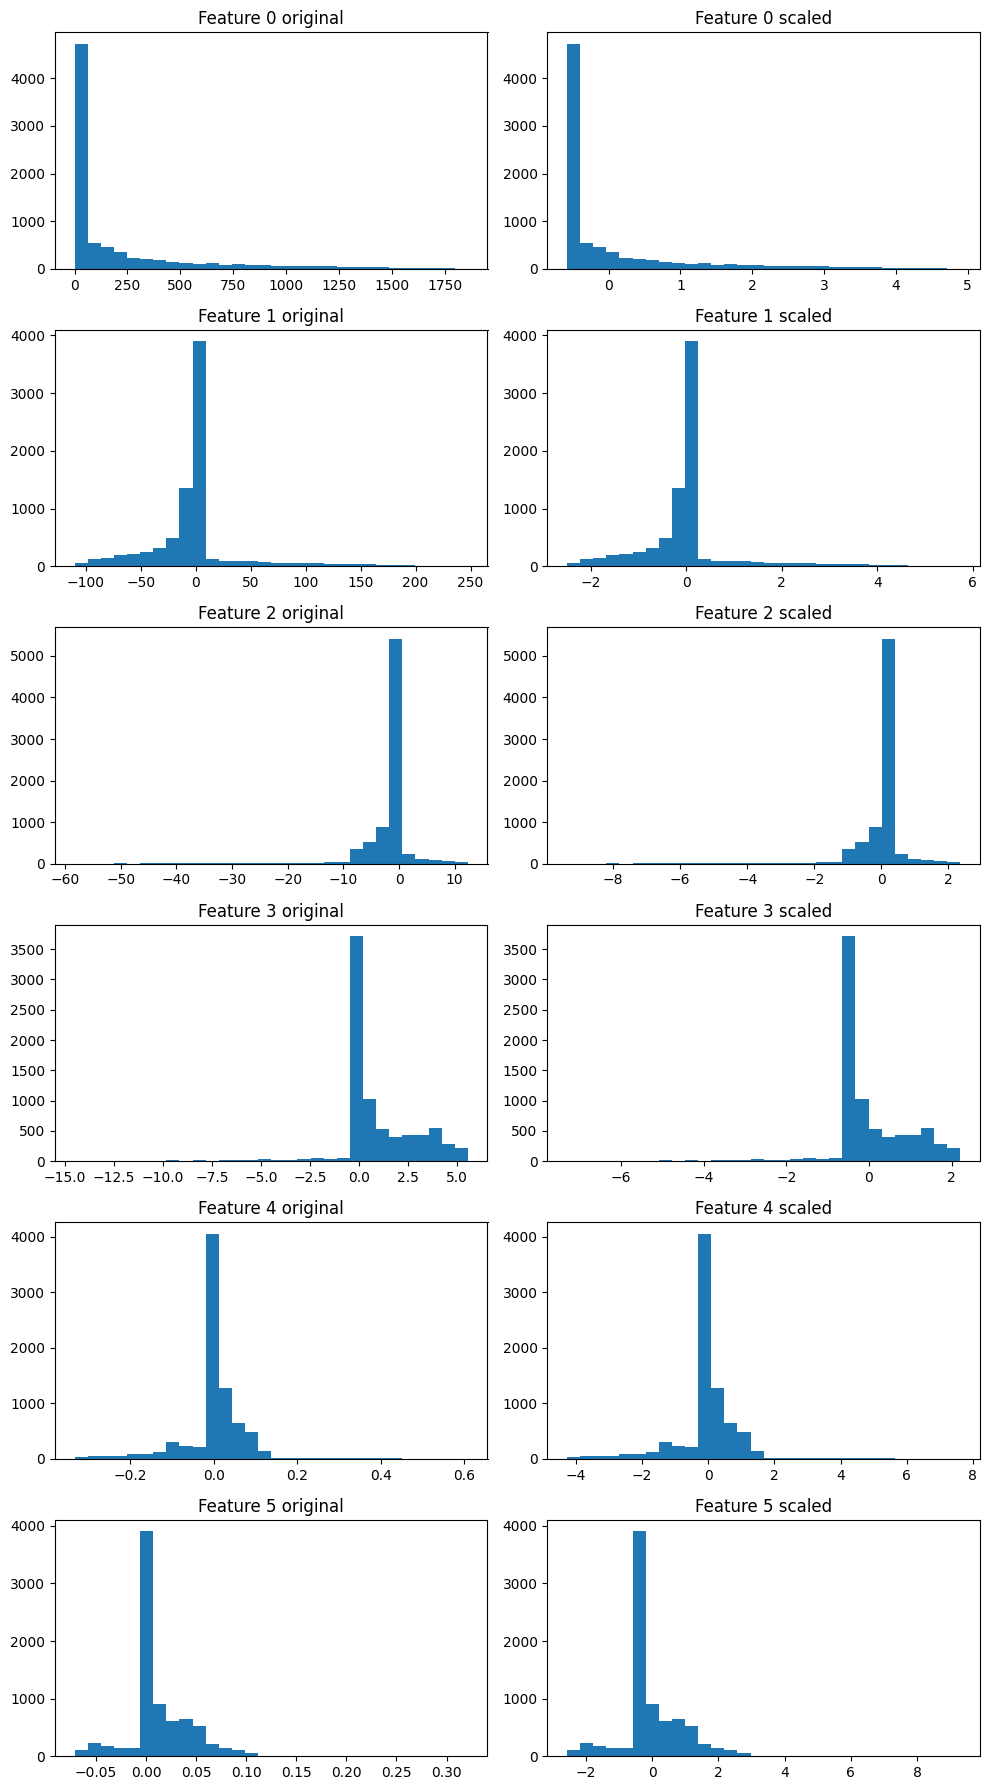

In [ ]:
# # fig, ax = plt.subplots(2, 6, figsize=(12, 4))

# # for i in range(6):
# #     scaled_weights = np.real(y_train[:, i])
# #     unscaled_weights = np.real(projected_coeffs_train[:, i])

# #     ax[0, i].hist(scaled_weights, bins=30)
# #     ax[1, i].hist(unscaled_weights, bins=30)

# #     ax[0, i].set_title(f"Scaled feature {i}")
# #     ax[1, i].set_title(f"Unscaled feature {i}")

# # plt.tight_layout()
# # plt.show()

# fig, ax = plt.subplots(6, 2, figsize=(10, 18))

# for i in range(6):
#     original = np.real(projected_coeffs_train[:, i])
#     scaled = np.real(y_train[:, i])

#     ax[i, 0].hist(original, bins=30)
#     ax[i, 0].set_title(f"Feature {i} original")

#     ax[i, 1].hist(scaled, bins=30)
#     ax[i, 1].set_title(f"Feature {i} scaled")

# plt.tight_layout()
# plt.show()

- This looks good. Now we train the NN. 
- We will train a fully connected model. 
- To determine the depth, width, and LR we will use for the model, I will run an optuna optimisation.
- All of this has been shifted to the optuna_optimize script.

In [15]:
class Emulator(nn.Module):
    def __init__(self, input_dim = 4, output_dim = n_comp, hidden_dim=64, num_layers=4):
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, hidden_dim)) # Defines the input
        for _ in range(num_layers):
            self.layers.append(nn.Linear(hidden_dim,hidden_dim))
        self.layers.append(nn.Linear(hidden_dim, output_dim))

    def forward(self, x):
        for layer in self.layers[:-1]: # [:-1] bc we do not want to relu the last laye
            x = torch.relu(layer(x))
        x = self.layers[-1](x)
        return x


In [16]:
# def train_model(model, x_train, y_train, x_val, y_val, optimiser, epochs=1000, 
#                 batch_size=128, verbose=True, plot=False, savefig=None, trial=None):
#     torch.manual_seed(1701)
#     train_losses = []
#     valid_losses = []
#     best_valid_loss = float("inf")
#     best_epoch = -1
#     best_state_dict = None

#     for epoch in range(epochs):
#         model.train()
#         total_train_loss = 0.0
#         num_batches = 0

#         # shuffling
#         perm = torch.randperm(len(x_train))
#         x_shuffled = x_train[perm]
#         y_shuffled = y_train[perm]

#         # go through this epoch's batches
#         for batch in range(0, len(x_shuffled), batch_size):
#             x_batch = x_shuffled[batch:batch + batch_size]
#             y_batch = y_shuffled[batch:batch + batch_size]

#             optimiser.zero_grad()
#             loss = nn.functional.mse_loss(model(x_batch), y_batch)
            
#             loss.backward()
#             optimiser.step()

#             total_train_loss += loss.item()
#             num_batches += 1

#         avg_train_loss = total_train_loss / num_batches
#         train_losses.append(avg_train_loss)

#         model.eval()
#         with torch.no_grad():
#             valid_loss = nn.functional.mse_loss(model(x_val), y_val)
        
#         valid_losses.append(valid_loss)

#         if valid_loss < best_valid_loss:
#             best_valid_loss = valid_loss
#             best_train_loss = avg_train_loss
#             best_epoch = epoch
#             best_state_dict = copy.deepcopy(model.state_dict())
        
#         if trial is not None:
#             trial.report(valid_loss, step=epoch)
#             if trial.should_prune():
#                 raise optuna.TrialPruned()
            
#         if verbose and (epoch % 100 == 0 or epoch == epochs - 1):
#             print(
#                 f"Epoch {epoch+1}/{epochs}, "
#                 f"Train Loss: {avg_train_loss:.4f}, "
#                 f"Valid Loss: {valid_loss:.4f}, "
#                 f"LR: {optimiser.param_groups[0]['lr']:.2e}"
#             )
#     if plot:
#         plt.plot(train_losses, label="Train Loss")
#         plt.plot(valid_losses, label="Validation Loss")
#         plt.xlabel("Epoch")
#         plt.ylabel("MSE")
#         plt.title("Training and Validation Loss")
#         plt.legend()
#         if savefig is not None:
#             plt.savefig(savefig)
#         plt.show()

#     if best_state_dict is not None:
#         model.load_state_dict(best_state_dict)


#     return best_valid_loss, best_train_loss, best_epoch, model # model is best model

    



# def objective(trial):
#     num_layers = trial.suggest_categorical("num_layers", [4,6])
#     hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64])
#     lr = trial.suggest_float("lr", 5e-5, 1e-2, log=True)
#     weight_decay = trial.suggest_float("weight_decay", 1e-8, 1e-3, log=True) # introduce a it of weight decay for stability
    
#     torch.manual_seed(1701)

#     model = Emulator(hidden_dim=hidden_dim, num_layers=num_layers)

#     optimiser = optim.Adam(
#         model.parameters(),
#         lr = lr,
#         weight_decay = weight_decay
#     )

#     best_valid_loss, best_train_loss, best_epoch, best_model = train_model(
#         model, x_train, y_train, x_val, y_val, optimiser, epochs=200, 
#         verbose=False, trial=trial
#     )

#     trial.set_user_attr("best_epoch", best_epoch)


#     return best_valid_loss

In [19]:
import copy

def train_model(model, x_train, y_train, x_val, y_val, optimiser, epochs=1000,
                batch_size=512, verbose=True, plot=False, savefig=None,
                trial=None, patience=100):
    torch.manual_seed(1701)

    train_losses = []
    valid_losses = []

    best_valid_loss = float("inf")
    best_train_loss = None
    best_epoch = -1
    best_state_dict = None

    epochs_since_improvement = 0

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        num_batches = 0

        perm = torch.randperm(len(x_train))
        x_shuffled = x_train[perm]
        y_shuffled = y_train[perm]

        for batch in range(0, len(x_shuffled), batch_size):
            x_batch = x_shuffled[batch:batch + batch_size]
            y_batch = y_shuffled[batch:batch + batch_size]

            optimiser.zero_grad()
            loss = nn.functional.mse_loss(model(x_batch), y_batch)
            loss.backward()
            optimiser.step()

            total_train_loss += loss.item()
            num_batches += 1

        avg_train_loss = total_train_loss / num_batches
        train_losses.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            valid_loss = nn.functional.mse_loss(model(x_val), y_val).item()

        valid_losses.append(valid_loss)

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_train_loss = avg_train_loss
            best_epoch = epoch
            best_state_dict = copy.deepcopy(model.state_dict())
            epochs_since_improvement = 0
        else:
            epochs_since_improvement += 1

        if trial is not None:
            trial.report(valid_loss, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if verbose and (epoch % 100 == 0 or epoch == epochs - 1):
            print(
                f"Epoch {epoch+1}/{epochs}, "
                f"Train Loss: {avg_train_loss:.4f}, "
                f"Valid Loss: {valid_loss:.4f}, "
                f"LR: {optimiser.param_groups[0]['lr']:.2e}"
            )

        if epochs_since_improvement >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}. Best epoch was {best_epoch+1}.")
            break

    if plot:
        plt.plot(train_losses, label="Train Loss")
        plt.plot(valid_losses, label="Validation Loss")
        plt.yscale("log")
        plt.xlabel("Epoch")
        plt.ylabel("MSE")
        plt.title("Training and Validation Loss")
        plt.legend()
        if savefig is not None:
            plt.savefig(savefig)
        plt.show()

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return best_valid_loss, best_train_loss, best_epoch, model


def objective(trial):
    num_layers = trial.suggest_categorical("num_layers", [3,4,5,6,7,8])
    hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64, 128])
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-8, 1e-3, log=True)

    torch.manual_seed(1701)

    model = Emulator(hidden_dim=hidden_dim, num_layers=num_layers)

    optimiser = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_valid_loss, best_train_loss, best_epoch, best_model = train_model(
        model, x_train, y_train, x_val, y_val, optimiser,
        epochs=1000, verbose=False, trial=trial, patience=200
    )

    trial.set_user_attr("best_epoch", best_epoch)
    trial.set_user_attr("best_train_loss", best_train_loss)

    return best_valid_loss

In [20]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

[I 2026-03-25 20:18:56,933] A new study created in memory with name: no-name-0c0c818b-7660-4ff1-9731-aaa8d4860272
[I 2026-03-25 20:19:34,956] Trial 0 finished with value: 0.0010944626992568374 and parameters: {'num_layers': 5, 'hidden_dim': 32, 'lr': 0.0009623480032211108, 'weight_decay': 2.055825928352093e-07}. Best is trial 0 with value: 0.0010944626992568374.
[I 2026-03-25 20:20:18,809] Trial 1 finished with value: 0.0017313079442828894 and parameters: {'num_layers': 7, 'hidden_dim': 32, 'lr': 0.0001780520190998842, 'weight_decay': 4.30913259197463e-06}. Best is trial 0 with value: 0.0010944626992568374.
[I 2026-03-25 20:20:53,516] Trial 2 finished with value: 0.0030551643576472998 and parameters: {'num_layers': 5, 'hidden_dim': 32, 'lr': 6.65400847855721e-05, 'weight_decay': 2.3681442010071853e-06}. Best is trial 0 with value: 0.0010944626992568374.
[I 2026-03-25 20:22:15,412] Trial 3 finished with value: 0.0004969645524397492 and parameters: {'num_layers': 7, 'hidden_dim': 128, 'l

In [21]:
print("Best trial:")
print("  value:", study.best_trial.value)
print("  params:", study.best_trial.params)
print("  best_epoch:", study.best_trial.user_attrs["best_epoch"])


Best trial:
  value: 0.0004969645524397492
  params: {'num_layers': 7, 'hidden_dim': 128, 'lr': 0.0005805761046276035, 'weight_decay': 6.273251620715951e-06}
  best_epoch: 942


Epoch 1/10000, Train Loss: 0.9996, Valid Loss: 1.0263, LR: 5.81e-04
Epoch 101/10000, Train Loss: 0.0036, Valid Loss: 0.0029, LR: 5.81e-04
Epoch 201/10000, Train Loss: 0.0015, Valid Loss: 0.0035, LR: 5.81e-04
Epoch 301/10000, Train Loss: 0.0107, Valid Loss: 0.0072, LR: 5.81e-04
Epoch 401/10000, Train Loss: 0.0008, Valid Loss: 0.0009, LR: 5.81e-04
Epoch 501/10000, Train Loss: 0.0013, Valid Loss: 0.0012, LR: 5.81e-04
Epoch 601/10000, Train Loss: 0.0014, Valid Loss: 0.0013, LR: 5.81e-04
Epoch 701/10000, Train Loss: 0.0005, Valid Loss: 0.0007, LR: 5.81e-04
Epoch 801/10000, Train Loss: 0.0007, Valid Loss: 0.0011, LR: 5.81e-04
Epoch 901/10000, Train Loss: 0.0004, Valid Loss: 0.0007, LR: 5.81e-04
Epoch 1001/10000, Train Loss: 0.0004, Valid Loss: 0.0011, LR: 5.81e-04
Epoch 1101/10000, Train Loss: 0.0004, Valid Loss: 0.0005, LR: 5.81e-04
Epoch 1201/10000, Train Loss: 0.0006, Valid Loss: 0.0006, LR: 5.81e-04
Epoch 1301/10000, Train Loss: 0.0002, Valid Loss: 0.0004, LR: 5.81e-04
Epoch 1401/10000, 

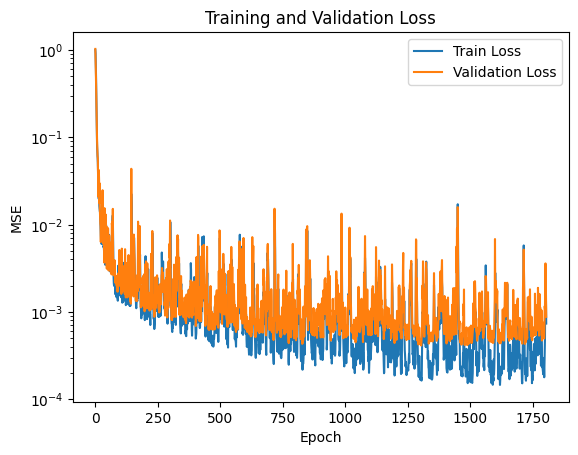

In [22]:
# Retrain best model on train + val and evaluate on test
best_params = study.best_trial.params
torch.manual_seed(1701)

best_model = Emulator(hidden_dim=best_params["hidden_dim"], num_layers=best_params["num_layers"])
best_optimizer = optim.Adam(
        best_model.parameters(),
        lr=best_params["lr"],
    )

        # weight_decay=best_params["weight_decay"],


best_valid_loss, best_train_loss, best_epoch, best_model = train_model(
        best_model, x_train, y_train, x_val, y_val, best_optimizer, epochs=10000, 
        verbose=True, trial=None, plot=True, patience=500
    )


### COMMENT

- Our best model is now stored as the best_model.
- We can now examing best_model's performance on the test set.

The test loss MSE is 4.809e-04 in normalised space


c:\Users\Joey\Desktop\Cambridge\Work\A1\A1CW\Machine-Learning-Enhanced-Inference-of-the-21-cm-Power-Spectrum-at-Cosmic-Dawn\VenvA1Cw\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Joey\Desktop\Cambridge\Work\A1\A1CW\Machine-Learning-Enhanced-Inference-of-the-21-cm-Power-Spectrum-at-Cosmic-Dawn\VenvA1Cw\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
c:\Users\Joey\Desktop\Cambridge\Work\A1\A1CW\Machine-Learning-Enhanced-Inference-of-the-21-cm-Power-Spectrum-at-Cosmic-Dawn\VenvA1Cw\lib\site-packages\matplotlib\transforms.py:984: ComplexWarning: Casting complex values to real discards the imaginary part
  self._points[:, 1] = interval


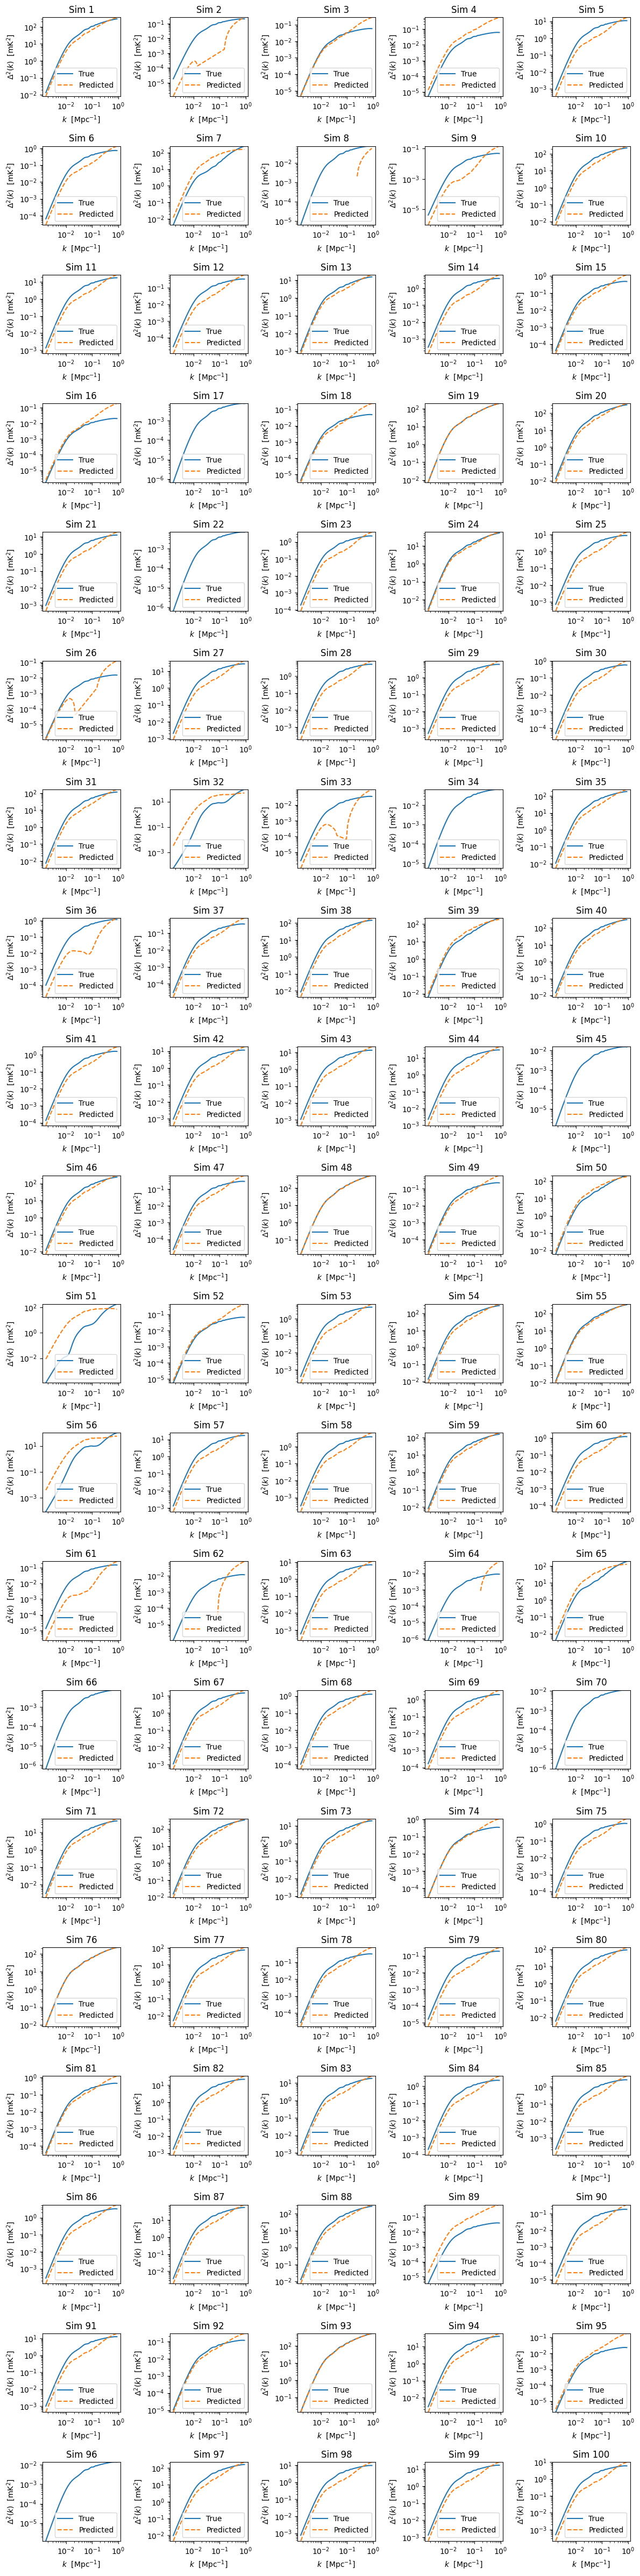

In [26]:
# Make the predictions
unscaled_pred_weights_test = best_model(x_test).detach().numpy()
test_loss = nn.functional.mse_loss(torch.tensor(unscaled_pred_weights_test), y_test).item()
print(f"The test loss MSE is {test_loss:.3e} in normalised space")

# Rescale our predictions
pred_weights_test = weight_scaler.inverse_transform(unscaled_pred_weights_test)
test_pred_spectra =  np.dot(pred_weights_test, evecs[:, :n_comp].T)

# # Plot a few as subplots
# fig, ax = plt.subplots(20,5, figsize = (12,48))
# for i in range(100):
#     ax[i//5, i%5].loglog(k_test[i], power_test[i], label='True')
#     ax[i//5, i%5].loglog(k_test[i], test_pred_spectra[i], label='Predicted', ls='--')
#     ax[i//5, i%5].set_xlabel(r'$k$  [Mpc$^{-1}$]')
#     ax[i//5, i%5].set_ylabel(r'$\Delta^2(k)$  [mK$^2$]')
#     ax[i//5, i%5].set_title(f'Sim {i+1}')
#     ax[i//5, i%5].legend()
# plt.tight_layout()
# plt.show()


fig, ax = plt.subplots(20, 5, figsize=(12, 48))

for i in range(100):
    true_y = power_test[i]
    pred_y = test_pred_spectra[i]
    x = k_test[i]

    # keep only points that are valid for log-log plotting
    mask_true = (x > 0) & (true_y > 0)
    mask_pred = (x > 0) & (pred_y > 0)

    ax[i//5, i%5].loglog(x[mask_true], true_y[mask_true], label='True')
    ax[i//5, i%5].loglog(x[mask_pred], pred_y[mask_pred], '--', label='Predicted')

    # force limits to include both curves
    y_all = np.concatenate([true_y[mask_true], pred_y[mask_pred]])
    if len(y_all) > 0:
        ax[i//5, i%5].set_ylim(y_all.min(), y_all.max())

    ax[i//5, i%5].set_xlabel(r'$k$  [Mpc$^{-1}$]')
    ax[i//5, i%5].set_ylabel(r'$\Delta^2(k)$  [mK$^2$]')
    ax[i//5, i%5].set_title(f'Sim {i+1}')
    ax[i//5, i%5].legend()

plt.tight_layout()
plt.show()

- These are mostly pretty good!
- Now we consider the fractional residual error across the test set.


Mean error:       248.504 %
95th percentile:  936.485 %


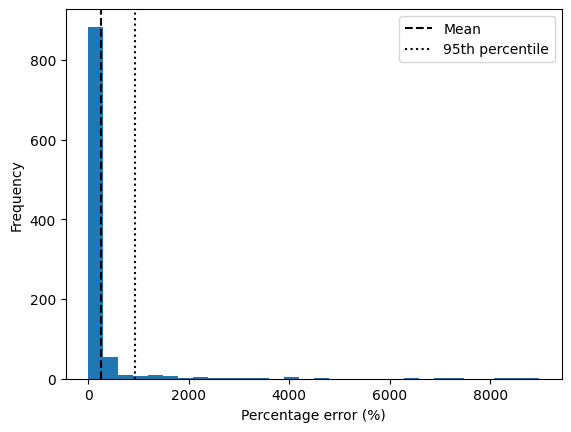

In [25]:
# test_frac_residuals = []
# mean_test_error = 100 * np.mean(
#     np.abs(power_test - test_pred_spectra) / np.abs(power_test),
#     axis=1
# )

test_frac_residuals = []
denom = np.maximum(np.abs(power_test), 1e-8)
mean_test_error = 100.0 * np.mean(
np.abs(power_test - test_pred_spectra) / denom,
axis=1,
)

print(f'Mean error:       {np.mean(mean_test_error):.3f} %')
print(f'95th percentile:  {np.quantile(mean_test_error, 0.95):.3f} %')

plt.hist(mean_test_error, bins=30)
plt.axvline(np.mean(mean_test_error),          label='Mean',          ls='--', c='k')
plt.axvline(np.quantile(mean_test_error, 0.95),label='95th percentile', ls=':',  c='k')
plt.xlabel('Percentage error (%)')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('errors.png', dpi=300, bbox_inches='tight')
plt.show()



---------------------------------------

In [ ]:
dataset1 = np.load(files[0], allow_pickle=True)
dataset1.files
k = dataset1["k"]
power = dataset1["power"]
astro_params = dataset1["astro_params"]
cosmo_params = dataset1["cosmo_params"]
redshifts = dataset1["redshfit"]
code = dataset1["code"]
code_version = dataset1["code_version"]

for name, value in {
    "k": k,
    "power": power,
    "astro_params": astro_params,
    "cosmo_params": cosmo_params,
    "redshifts": redshifts,
    "code": code,
    "code_version": code_version,
}.items():
    print(f"{name}: {np.shape(value)}")

# print(k)
print(power)
print(np.log(min(power)), np.log(max(power)))
# print(astro_params)
# print(cosmo_params)
# print(redshifts)
# print(code)
# print(code_version)

k: (54,)
power: (54,)
astro_params: ()
cosmo_params: ()
redshifts: ()
code: ()
code_version: ()
[7.47685668e-03 1.17543845e-02 1.84238133e-02 2.87766302e-02
 4.47646190e-02 6.93055195e-02 1.06708847e-01 1.63245637e-01
 2.47878651e-01 3.73112822e-01 5.55905140e-01 8.18373566e-01
 1.18797717e+00 1.69641376e+00 2.37663902e+00 3.25690954e+00
 4.35249707e+00 5.65582583e+00 7.13087339e+00 8.71596303e+00
 1.03440688e+01 1.19720621e+01 1.36169846e+01 1.53657351e+01
 1.73573602e+01 1.97819180e+01 2.28448366e+01 2.66964759e+01
 3.11004660e+01 3.50089825e+01 3.71703915e+01 3.82915299e+01
 4.12093427e+01 4.74106189e+01 5.26737507e+01 5.31096109e+01
 5.61649336e+01 6.30732838e+01 6.40220110e+01 6.90476713e+01
 7.24870554e+01 7.67418995e+01 7.99308894e+01 8.42847893e+01
 8.80104033e+01 9.18137867e+01 9.56606479e+01 9.93856162e+01
 1.02964900e+02 1.06345587e+02 1.09440159e+02 1.12026565e+02
 1.13814238e+02 1.14498132e+02]
-4.895942805268216 4.740558504202362
